In [4]:
"""
Visualization 1: Time-Series of KSI Collisions in Toronto

Purpose:
This script loads the Toronto Police KSI collision dataset,
aggregates the data by year, and generates a line chart showing
temporal trends in killed or seriously injured traffic collisions.

Author: Yutong Wang
Date: 2026/02/01
"""

'\nVisualization 1: Time-Series of KSI Collisions in Toronto\n\nPurpose:\nThis script loads the Toronto Police KSI collision dataset,\naggregates the data by year, and generates a line chart showing\ntemporal trends in killed or seriously injured traffic collisions.\n\nAuthor: Yutong Wang\nDate: 2026/02/01\n'

In [14]:
# =========================
# 1. Import required libraries
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

In [15]:
# =========================
# 2. Load the dataset
# =========================
# Replace with the correct path to your CSV file
df = pd.read_csv("ksi_collisions.csv")

In [ ]:
# =========================
# 3. Generate yearly KSI summary table (2006–2024)
# =========================
ksi_year_table = (
    df.groupby("ACCIDENT_YEAR")
      .size()
      .reset_index(name="KSI_Collisions")
)

ksi_year_table = ksi_year_table[
    (ksi_year_table["ACCIDENT_YEAR"] >= 2006) &
    (ksi_year_table["ACCIDENT_YEAR"] <= 2024)
].sort_values("ACCIDENT_YEAR")

# Save table for data transparency & ensure reproducibility 
ksi_year_table.to_csv(
    "ksi_collisions_by_year_2006_2024.csv",
    index=False
)

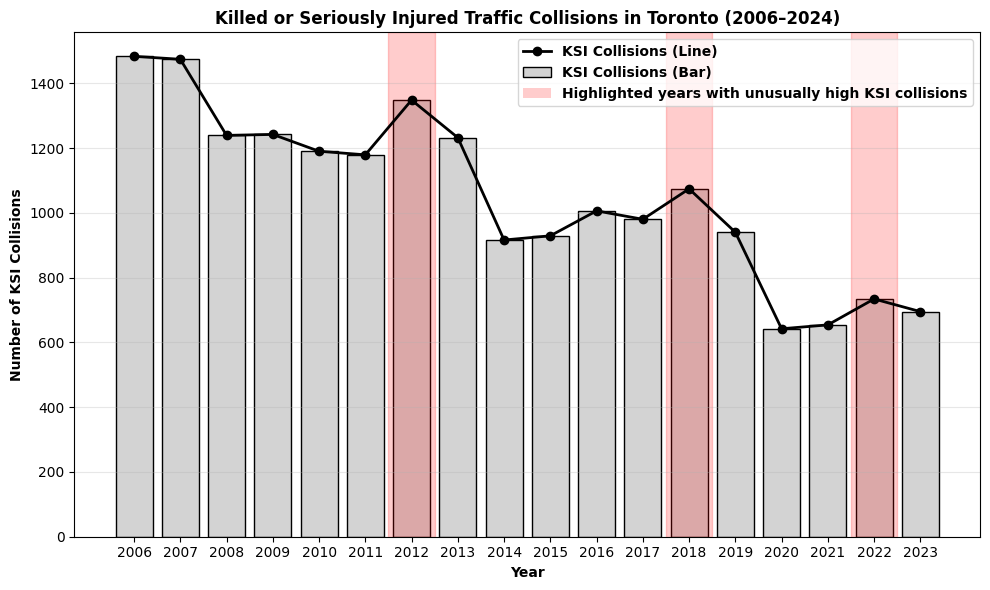

In [20]:
# =========================
# 5. Create visualization (bar + line)
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart (magnitude)
ax.bar(
    ksi_year_table["ACCIDENT_YEAR"],
    ksi_year_table["KSI_Collisions"],
    color="lightgray",
    edgecolor="black",
    label="KSI Collisions (Bar)"
)

# Line chart (trend)
ax.plot(
    ksi_year_table["ACCIDENT_YEAR"],
    ksi_year_table["KSI_Collisions"],
    marker="o",
    linewidth=2,
    color="black",
    label="KSI Collisions (Line)"
)

# =========================
# 6. Highlight spike years with red boxes
# =========================
highlight_years = [2012, 2018, 2022]

for year in highlight_years:
    ax.axvspan(
        year - 0.5,
        year + 0.5,
        color="red",
        alpha=0.2
    )

highlight_patch = Patch(
    facecolor="red",
    alpha=0.2,
    label="Highlighted years with unusually high KSI collisions"
)

handles, labels = ax.get_legend_handles_labels()
handles.append(highlight_patch)
labels.append("Highlighted years with unusually high KSI collisions")

ax.legend(handles, labels, prop={"weight": "bold"})

# =========================
# 8. Final formatting
# =========================
ax.set_title(
    "Killed or Seriously Injured Traffic Collisions in Toronto (2006–2024)",
    fontweight="bold"
)
ax.set_xlabel("Year",fontweight="bold")
ax.set_ylabel("Number of KSI Collisions", fontweight="bold")

ax.set_ylim(bottom=0)
ax.set_xticks(ksi_year_table["ACCIDENT_YEAR"])

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()


# =========================
# 9. Show plot
# =========================
plt.show()

In [ ]:
# Export dataset for visualization_2 plot
ksi_neigh_table = (
    df.groupby("NEIGHBOURHOOD_140")
      .size()
      .reset_index(name="KSI_Collisions")
)

ksi_neigh_table.to_csv(
    "ksi_collisions_by_neighbourhood.csv",
    index=False
)

print("Export complete: ksi_collisions_by_neighbourhood.csv")

Export complete: ksi_collisions_by_neighbourhood.csv
